In [17]:
from datamodel import Order, OrderDepth, Product
from statistics import NormalDist
from math import sqrt, log, pi, exp
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [18]:
class BlackScholes:
    @staticmethod
    def black_scholes_call(spot, strike, time, vol):
        d1 = (log(spot / strike) + (0.5 * vol**2) * time) / (vol * sqrt(time))
        d2 = d1 - vol * sqrt(time)
        return spot * NormalDist().cdf(d1) - strike * NormalDist().cdf(d2)

    @staticmethod
    def implied_volatility(price, spot, strike, time, max_iter=100, tol=1e-8):
        low, high = 0.01, 1.0
        for _ in range(max_iter):
            mid = (low + high) / 2
            est = BlackScholes.black_scholes_call(spot, strike, time, mid)
            if abs(est - price) < tol:
                return mid
            if est > price:
                high = mid
            else:
                low = mid
        return mid

    @staticmethod
    def delta(spot, strike, time, vol):
        d1 = (log(spot / strike) + (0.5 * vol**2) * time) / (vol * sqrt(time))
        return NormalDist().cdf(d1)

In [19]:
class CoconutHedger:
    def __init__(self, limit):
        self.limit = limit

    def hedge_position(self, order_depth: OrderDepth, target_position, current_position):
        orders = []
        quantity_needed = target_position - current_position

        if quantity_needed > 0:
            # Buy
            best_ask = min(order_depth.sell_orders.keys())
            quantity = min(quantity_needed, -order_depth.sell_orders[best_ask], self.limit - current_position)
            if quantity > 0:
                orders.append(Order(Product.COCONUT, best_ask, quantity))

        elif quantity_needed < 0:
            # Sell
            best_bid = max(order_depth.buy_orders.keys())
            quantity = min(-quantity_needed, order_depth.buy_orders[best_bid], self.limit + current_position)
            if quantity > 0:
                orders.append(Order(Product.COCONUT, best_bid, -quantity))

        return orders


In [20]:
class CoconutCouponTrader:
    def __init__(self, params, limit):
        self.params = params
        self.limit = limit

    def get_mid_price(self, order_depth: OrderDepth, trader_data: dict):
        if order_depth.buy_orders and order_depth.sell_orders:
            best_bid = max(order_depth.buy_orders.keys())
            best_ask = min(order_depth.sell_orders.keys())
            mid_price = (best_bid + best_ask) / 2
            trader_data["prev_coupon_price"] = mid_price
            return mid_price
        return trader_data.get("prev_coupon_price", 0)

    def generate_coupon_orders(self, order_depth: OrderDepth, position, trader_data: dict, volatility: float):
        trader_data["past_coupon_vol"].append(volatility)

        if len(trader_data["past_coupon_vol"]) > self.params["std_window"]:
            trader_data["past_coupon_vol"].pop(0)

        if len(trader_data["past_coupon_vol"]) < self.params["std_window"]:
            return None, None

        zscore = (
            (volatility - self.params["mean_volatility"])
            / np.std(trader_data["past_coupon_vol"])
        )

        orders, quotes = [], []

        if zscore >= self.params["zscore_threshold"]:
            target_pos = -self.limit
            if position > target_pos:
                best_bid = max(order_depth.buy_orders.keys())
                available_qty = order_depth.buy_orders[best_bid]
                quantity = min(position - target_pos, available_qty)
                quote_qty = (position - target_pos) - quantity
                if quantity > 0:
                    orders.append(Order(Product.COCONUT_COUPON, best_bid, -quantity))
                if quote_qty > 0:
                    quotes.append(Order(Product.COCONUT_COUPON, best_bid, -quote_qty))

        elif zscore <= -self.params["zscore_threshold"]:
            target_pos = self.limit
            if position < target_pos:
                best_ask = min(order_depth.sell_orders.keys())
                available_qty = -order_depth.sell_orders[best_ask]
                quantity = min(target_pos - position, available_qty)
                quote_qty = (target_pos - position) - quantity
                if quantity > 0:
                    orders.append(Order(Product.COCONUT_COUPON, best_ask, quantity))
                if quote_qty > 0:
                    quotes.append(Order(Product.COCONUT_COUPON, best_ask, quote_qty))

        return orders or None, quotes or None


In [21]:
def normal_pdf(x):
    return (1 / sqrt(2 * pi)) * exp(-0.5 * x**2)

def theta_call(S, K, T, r, sigma):
    d1 = (log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    N = NormalDist().cdf
    theta = (-S * normal_pdf(d1) * sigma) / (2 * sqrt(T)) - r * K * exp(-r * T) * N(d2)
    return theta

In [22]:
market_data = pd.read_csv(r"C:\Users\Can\OneDrive\Desktop\IMC\R3\round-3-island-data-bottle\prices_round_3_day_2.csv", sep=";", header=0)
market_data = pd.read_csv(r"1fd0f945-4de2-4d4f-98ab-e2127041d775.csv", sep=";", header=0)

product1 = 'VOLCANIC_ROCK'
product2 = 'VOLCANIC_ROCK_VOUCHER_9500'
product3 = 'VOLCANIC_ROCK_VOUCHER_9750'
product4 = 'VOLCANIC_ROCK_VOUCHER_10000'
product5 = 'VOLCANIC_ROCK_VOUCHER_10250'
product6 = 'VOLCANIC_ROCK_VOUCHER_10500'

m1 = market_data[market_data['product'] == product1].reset_index()
m2 = market_data[market_data['product'] == product2].reset_index()
m3 = market_data[market_data['product'] == product3].reset_index()
m4 = market_data[market_data['product'] == product4].reset_index()
m5 = market_data[market_data['product'] == product5].reset_index()
m6 = market_data[market_data['product'] == product6].reset_index()

for i in range(len(m2.index)):
    tte = (5 - m2.loc[i,'timestamp']/1000000)/250
    
    m2.loc[i, 'vol'] = BlackScholes.implied_volatility(m2.loc[i,'mid_price'], m1.loc[i,'mid_price'], 9500, tte)
    m3.loc[i, 'vol'] = BlackScholes.implied_volatility(m3.loc[i,'mid_price'], m1.loc[i,'mid_price'], 9750, tte)
    m4.loc[i, 'vol'] = BlackScholes.implied_volatility(m4.loc[i,'mid_price'], m1.loc[i,'mid_price'], 10000, tte)
    m5.loc[i, 'vol'] = BlackScholes.implied_volatility(m5.loc[i,'mid_price'], m1.loc[i,'mid_price'], 10250, tte)
    m6.loc[i, 'vol'] = BlackScholes.implied_volatility(m6.loc[i,'mid_price'], m1.loc[i,'mid_price'], 10500, tte)

    m2.loc[i, 'theta'] = theta_call(m1.loc[i,'mid_price'], 9500, tte, 0, m2.loc[i, 'vol'])
    m3.loc[i, 'theta'] = theta_call(m1.loc[i,'mid_price'], 9750, tte, 0, m3.loc[i, 'vol'])
    m4.loc[i, 'theta'] = theta_call(m1.loc[i,'mid_price'], 10000, tte, 0, m4.loc[i, 'vol'])
    m5.loc[i, 'theta'] = theta_call(m1.loc[i,'mid_price'], 10250, tte, 0, m5.loc[i, 'vol'])
    m6.loc[i, 'theta'] = theta_call(m1.loc[i,'mid_price'], 10500, tte, 0, m6.loc[i, 'vol'])

for i in range(len(m2.index)):
    m2.loc[i, 'delta'] = BlackScholes.delta(m2.loc[i,'mid_price'], m1.loc[i,'mid_price'], 9500, tte)
    m3.loc[i, 'delta'] = BlackScholes.delta(m3.loc[i,'mid_price'], m1.loc[i,'mid_price'], 9750, tte)
    m4.loc[i, 'delta'] = BlackScholes.delta(m4.loc[i,'mid_price'], m1.loc[i,'mid_price'], 10000, tte)
    m5.loc[i, 'delta'] = BlackScholes.delta(m5.loc[i,'mid_price'], m1.loc[i,'mid_price'], 10250, tte)
    m6.loc[i, 'delta'] = BlackScholes.delta(m6.loc[i,'mid_price'], m1.loc[i,'mid_price'], 10500, tte)


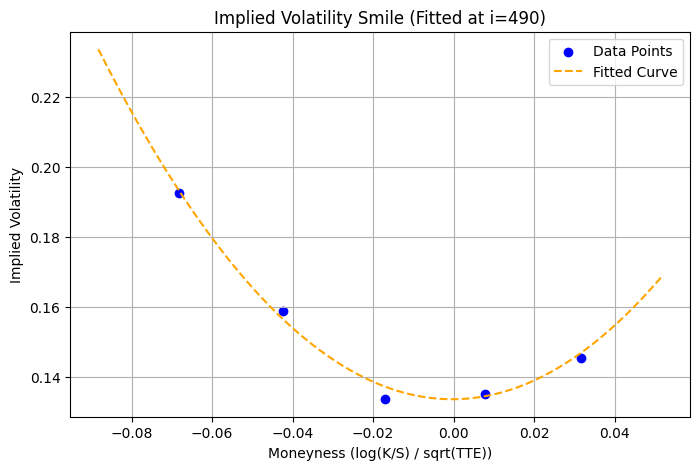

In [23]:
i = 490
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

i =500
strikes = np.array([9500, 9750, 10000, 10250, 10500])
vols = np.array([m2.loc[i,'vol'], m3.loc[i,'vol'], m4.loc[i,'vol'], m5.loc[i,'vol'], m6.loc[i,'vol']])  # 假定 vol 数据

spot = m1.loc[i, 'mid_price']

TTE = 1.0
m_list = np.log(strikes / spot) / np.sqrt(TTE)
v_list = vols

# Step 2: 拟合二次多项式
coeffs = np.polyfit(m_list, v_list, deg=2)
coeffs = [1.29013305e+01, 8.95916961e-03, 1.33738838e-01]
fit = np.poly1d(coeffs)

# Step 3: 画图
m_range = np.linspace(min(m_list) - 0.02, max(m_list) + 0.02, 200)
v_fit = fit(m_range)

# 绘图
plt.figure(figsize=(8, 5))
plt.scatter(m_list, v_list, label="Data Points", color='blue')
plt.plot(m_range, v_fit, label="Fitted Curve", linestyle='--', color='orange')
plt.title("Implied Volatility Smile (Fitted at i=490)")
plt.xlabel("Moneyness (log(K/S) / sqrt(TTE))")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid(True)
plt.show()


<Axes: >

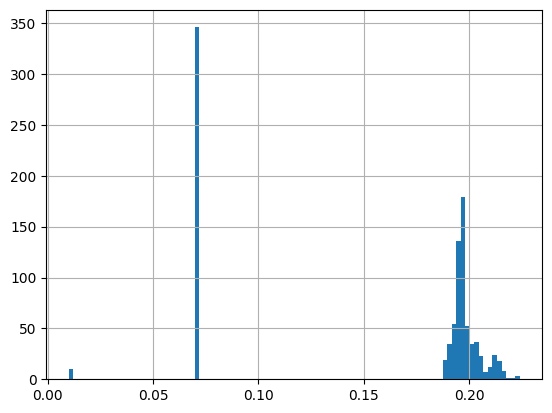

In [28]:
m2.vol.hist(bins=100)

In [29]:
m2.vol.min()

np.float64(0.010000000000000002)

In [25]:
tl = 0.01
tu = 0.01
cash = 0
position1 = 0
position2 = 0

for i in range(len(m2.index)):
    if m2.loc[i,'vol']< tl:
        if not np.isnan(m2.loc[i,'ask_price_1']):
            cash -= m2.loc[i,'ask_price_1'] * m2.loc[i,'ask_volume_1']
            position1 += m2.loc[i,'ask_volume_1']
        if not np.isnan(m1.loc[i,'bid_price_1']):
            cash += m1.loc[i,'bid_price_1'] * m1.loc[i,'bid_volume_1']
            position2 -= m1.loc[i,'bid_volume_1']

    if m2.loc[i,'vol'] > tu:
        if not np.isnan(m2.loc[i,'bid_price_1']):
            cash += m2.loc[i,'bid_price_1'] * m2.loc[i,'bid_volume_1']
            position1 -= m2.loc[i,'bid_volume_1']
        if not np.isnan(m1.loc[i,'ask_price_1']):    
            cash -= m1.loc[i,'ask_price_1'] * m1.loc[i,'ask_volume_1']
            position2 += m1.loc[i,'ask_volume_1']

cash = cash + position1*m2.loc[9999,'mid_price'] + position2*m1.loc[9999,'mid_price']
cash

KeyError: 9999

In [ ]:
bool(np.isnan(cash))

False

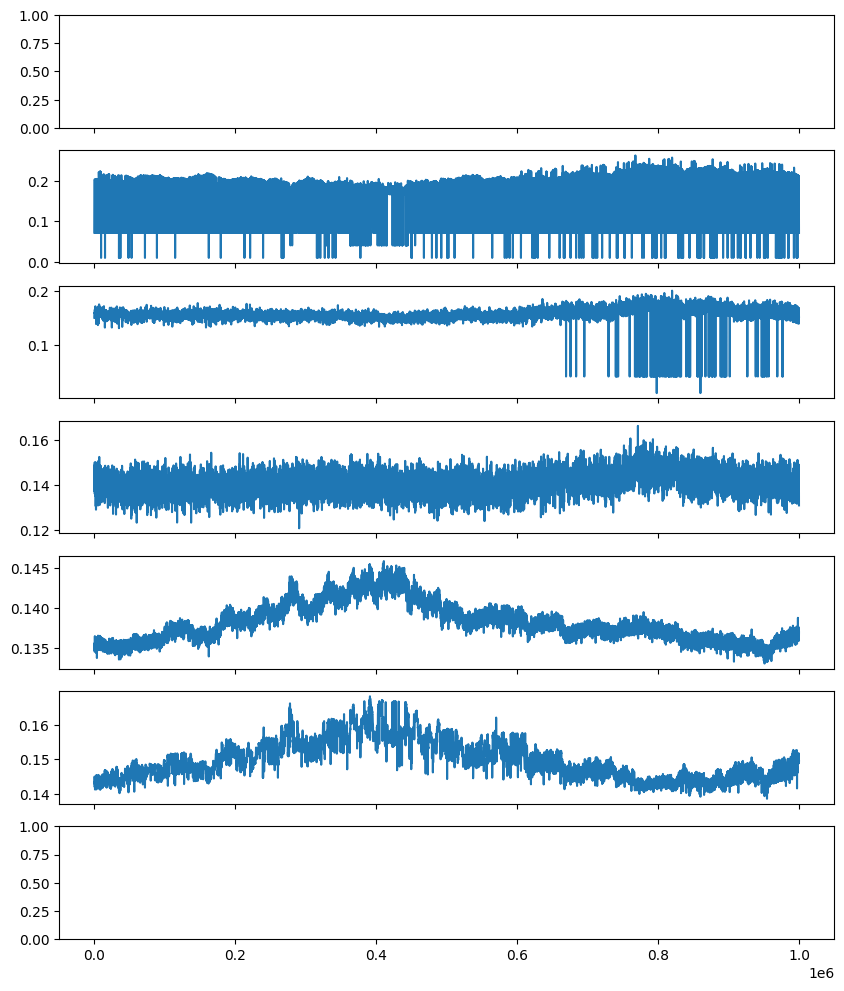

In [ ]:
fig, axs = plt.subplots(7, 1, figsize=(10, 12), sharex=True)
axs[1].plot(m2.timestamp, m2.vol)
axs[2].plot(m2.timestamp, m3.vol)
axs[3].plot(m2.timestamp, m4.vol)
axs[4].plot(m2.timestamp, m5.vol)
axs[5].plot(m2.timestamp, m6.vol)

[]

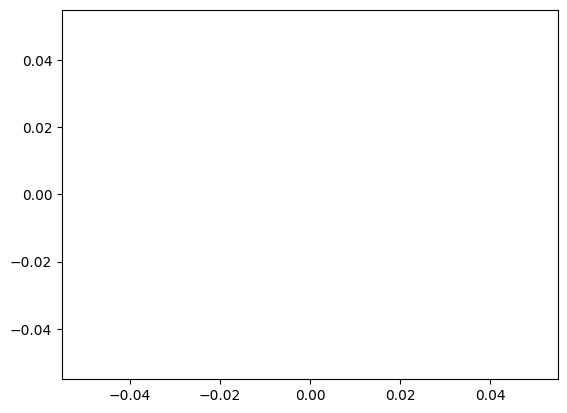

In [ ]:
plt.plot()

<Axes: >

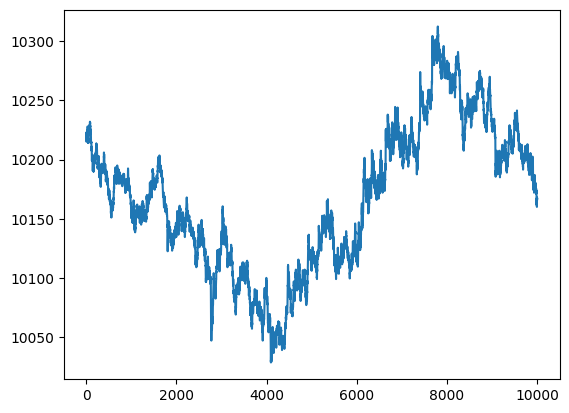

In [ ]:
m1.mid_price.plot()

In [ ]:
m1['delta'] = m1['mid_price'] - m1['mid_price'].shift(1)
m1['delta_9500'] = m2['mid_price'] - m2['mid_price'].shift(1)
m1['delta_9750'] = m3['mid_price'] - m3['mid_price'].shift(1)
m1['delta_10000'] = m4['mid_price'] - m4['mid_price'].shift(1)
m1['delta_10250'] = m5['mid_price'] - m5['mid_price'].shift(1)
m1['delta_1050'] = m6['mid_price'] - m6['mid_price'].shift(1)

In [ ]:
m2

,index,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,...,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,vol,theta,delta
0,3,2,0,VOLCANIC_ROCK_VOUCHER_9500,718.0,11.0,NaN,NaN,NaN,NaN,...,11,NaN,NaN,NaN,NaN,718.5,0.0,0.071875,-6.726650e-09,0.178123
1,22,2,100,VOLCANIC_ROCK_VOUCHER_9500,717.0,19.0,NaN,NaN,NaN,NaN,...,19,NaN,NaN,NaN,NaN,718.0,0.0,0.202713,-1.119482e+02,0.178023
2,41,2,200,VOLCANIC_ROCK_VOUCHER_9500,722.0,15.0,NaN,NaN,NaN,NaN,...,15,NaN,NaN,NaN,NaN,722.5,0.0,0.203799,-1.120680e+02,0.178995
3,45,2,300,VOLCANIC_ROCK_VOUCHER_9500,723.0,16.0,NaN,NaN,NaN,NaN,...,16,NaN,NaN,NaN,NaN,723.5,0.0,0.204042,-1.120962e+02,0.179211
4,68,2,400,VOLCANIC_ROCK_VOUCHER_9500,717.0,16.0,NaN,NaN,NaN,NaN,...,16,NaN,NaN,NaN,NaN,717.5,0.0,0.202599,-1.119418e+02,0.177915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,139933,2,999500,VOLCANIC_ROCK_VOUCHER_9500,667.0,5.0,NaN,NaN,NaN,NaN,...,20,NaN,NaN,NaN,NaN,668.0,0.0,0.071875,-8.262654e-10,0.166998
9996,139953,2,999600,VOLCANIC_ROCK_VOUCHER_9500,667.0,14.0,NaN,NaN,NaN,NaN,...,14,NaN,NaN,NaN,NaN,667.5,0.0,0.212943,-1.382060e+02,0.166894
9997,139961,2,999700,VOLCANIC_ROCK_VOUCHER_9500,667.0,13.0,NaN,NaN,NaN,NaN,...,13,NaN,NaN,NaN,NaN,667.5,0.0,0.212945,-1.382094e+02,0.166894
9998,139974,2,999800,VOLCANIC_ROCK_VOUCHER_9500,667.0,20.0,NaN,NaN,NaN,NaN,...,20,NaN,NaN,NaN,NaN,667.5,0.0,0.071875,-8.585507e-10,0.166886
